# Capability Tree

This notebook tests my custom capability tree functions to ensure they work correctly.

Display several levels of a benchmark's capability tree using my code to see if it matches the capability tree on EvalTree's [web demo](https://zhiyuan-zeng.github.io/EvalTree/).

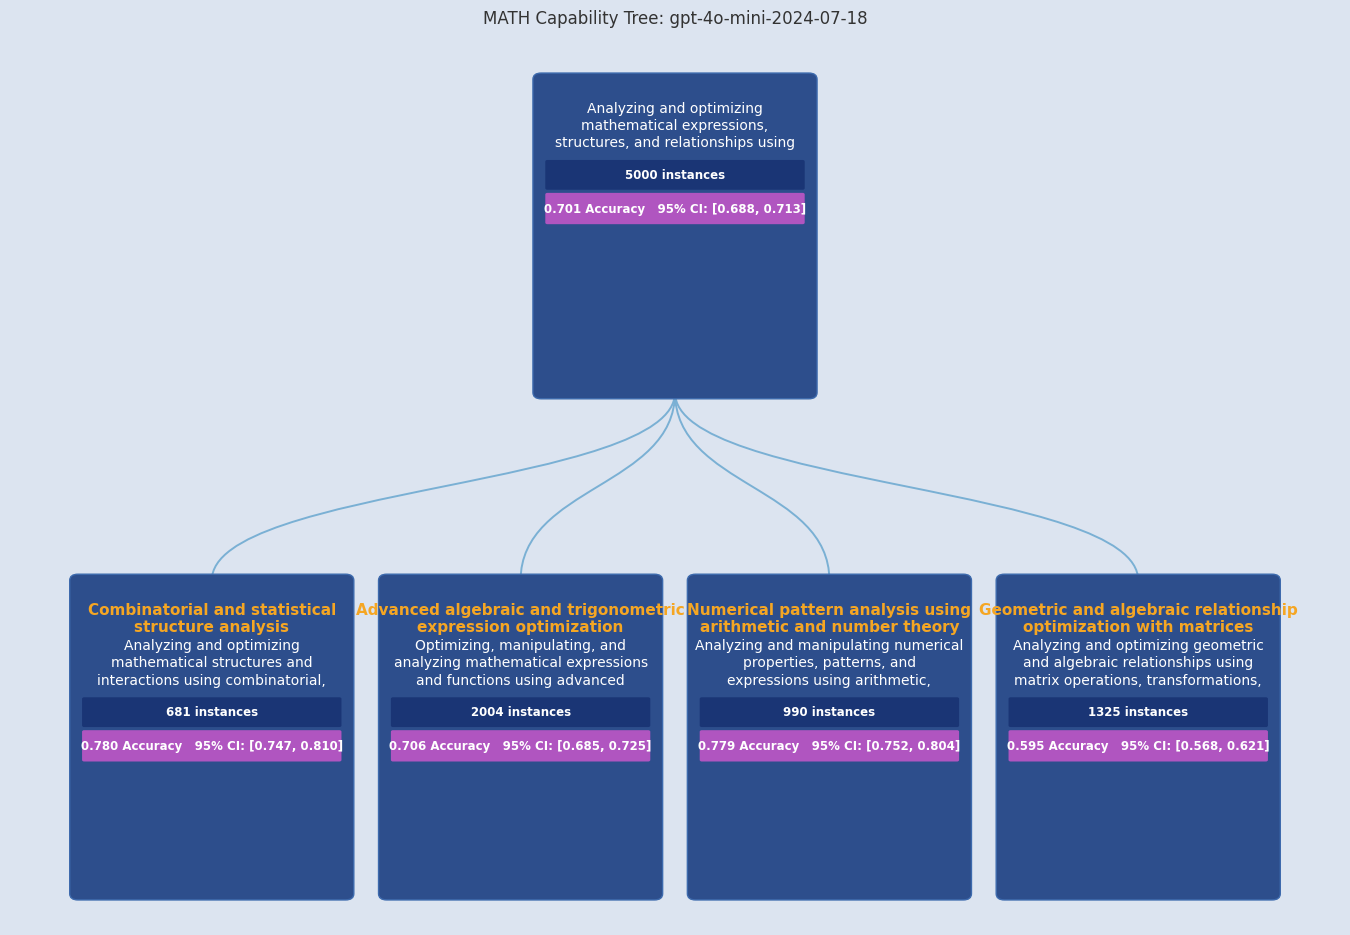

In [13]:
from dataclasses import fields

from src.utils.capability_tree import (
    load_capability_tree,
    collect_nodes_bfs,
    collect_nodes_dfs,
    get_node_indices,
)
from src.utils.enums import Dataset
from src.utils.model import load_model_scores
from src.utils.plot import plot_capability_tree

name = Dataset.MATH
dataset = Dataset(name)
model = dataset.models[0]
num_levels = 2

root = load_capability_tree(dataset)
plot_capability_tree(dataset, root, model, num_levels)

- Upon manual inspection, it looks like my plot matches EvalTree's web demo.

Collect some nodes in a depth-first manner and view their attributes.

In [14]:
min_instances = 0
nodes = collect_nodes_dfs(root, min_instances=min_instances)
metric = dataset.metric

first = nodes[0]
print(f"Fields: {', '.join([f.name for f in fields(first)])}\n")

num_preview = 3
for i in range(num_preview):
    node = nodes[i]
    print(f"Level {node.depth}:")
    print(f"  {node.distinction}")
    # print(f"  Capability: {node.capability}")
    print(f"  {node.size} instances")
    print(
        f"  {node.ranking[model]:.3f} {metric.title()}"
        f"  95% CI: [{node.CI[model][0]:.3f}, {node.CI[model][1]:.3f}]"
    )
    print()

Fields: capability, size, depth, subtrees, ranking, CI, distinction, input

Level 2:
  Geometric and algebraic relationship optimization with matrices
  1325 instances
  0.595 Accuracy  95% CI: [0.568, 0.621]

Level 3:
  Vector operations in multi-dimensional spaces
  105 instances
  0.467 Accuracy  95% CI: [0.369, 0.567]

Level 4:
  Vector algebra for geometric intersections
  18 instances
  0.278 Accuracy  95% CI: [0.097, 0.535]



- Upon manual inspection, it looks like the values produced by my code match EvalTree's web demo.

Collect some nodes in a breadth-first manner and view their attributes.

In [15]:
min_instances = 0
levels = collect_nodes_bfs(root, min_instances=min_instances)

num_preview = 2

for i, level in enumerate(levels):
    if level.depth > num_preview:
        break
    print(
        f"Level {level.depth}: {level.num_nodes} nodes, {level.num_instances} instances:"
    )
    for node in level.nodes:
        print(f"  {node.distinction}")
        # print(f"  Capability: {node.capability}")
        print(f"  {node.size} instances")
        print(
            f"  {node.ranking[model]:.3f} {metric.title()}"
            f"  95% CI: [{node.CI[model][0]:.3f}, {node.CI[model][1]:.3f}]"
        )
        print()

Level 1: 4 nodes, 5000 instances:
  Combinatorial and statistical structure analysis
  681 instances
  0.780 Accuracy  95% CI: [0.747, 0.810]

  Advanced algebraic and trigonometric expression optimization
  2004 instances
  0.706 Accuracy  95% CI: [0.685, 0.725]

  Numerical pattern analysis using arithmetic and number theory
  990 instances
  0.779 Accuracy  95% CI: [0.752, 0.804]

  Geometric and algebraic relationship optimization with matrices
  1325 instances
  0.595 Accuracy  95% CI: [0.568, 0.621]

Level 2: 27 nodes, 5000 instances:
  Combinatorial reasoning in discrete structures
  79 instances
  0.759 Accuracy  95% CI: [0.650, 0.849]

  Combinatorial structures and constraints analysis
  135 instances
  0.889 Accuracy  95% CI: [0.823, 0.936]

  Statistical measures and distributions manipulation
  86 instances
  0.860 Accuracy  95% CI: [0.769, 0.926]

  Probabilistic and combinatorial reasoning
  166 instances
  0.705 Accuracy  95% CI: [0.629, 0.773]

  Numerical and financia

- Upon manual inspection, it looks like the values produced by my code match EvalTree's web demo.